# Práctico 1: EDA y Visualización

Esta notebook traduce las consignas de `practico/practico_1.md` a un flujo de trabajo ejecutable y ordenado.

## Objetivo
Explorar los datos de adopción de IA para: 
1. Entender su estructura y calidad.
2. Describir variables clave de manera univariada.
3. Analizar relaciones bivariadas relevantes para el proyecto.
4. Formular hipóesis de investigación para los próximos prácticos.

## 1) Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2) Carga de datos

Esta celda carga los tres archivos provistos en `data/raw/`:
- `ai_company_adoption.csv`
- `ai_industry_summary.csv`
- `country_ai_index.csv`

Usamos rutas relativas desde la carpeta `notebook/` para facilitar portabilidad del proyecto.
Finalmente, mostramos las dimensiones iniciales para validar que la lectura fue correcta.

In [3]:
company = pd.read_csv('C:/Users/Seba/Documents/Proyectos/DiploDatos/data/raw/ai_company_adoption.csv')
industry = pd.read_csv('C:/Users/Seba/Documents/Proyectos/DiploDatos/data/raw/ai_industry_summary.csv')
country = pd.read_csv('C:/Users/Seba/Documents/Proyectos/DiploDatos/data/raw/country_ai_index.csv')

print('company:', company.shape)
print('industry:', industry.shape)
print('country:', country.shape)

company: (150025, 43)
industry: (9, 8)
country: (30, 8)


In [4]:
company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150025 entries, 0 to 150024
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150025 non-null  int64  
 1   company_id                   150025 non-null  object 
 2   survey_year                  150024 non-null  float64
 3   quarter                      150025 non-null  object 
 4   country                      150024 non-null  object 
 5   region                       150024 non-null  object 
 6   industry                     147772 non-null  object 
 7   company_size                 147774 non-null  object 
 8   num_employees                150025 non-null  float64
 9   annual_revenue_usd_millions  147778 non-null  float64
 10  company_founding_year        150025 non-null  float64
 11  company_age                  150025 non-null  float64
 12  company_age_group            150024 non-null  object 
 13 

In [5]:
industry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   industry                         9 non-null      object 
 1   avg_ai_adoption_rate             9 non-null      float64
 2   avg_productivity_change_percent  9 non-null      float64
 3   avg_ai_maturity_score            9 non-null      float64
 4   avg_ai_failure_rate              9 non-null      float64
 5   avg_jobs_displaced               9 non-null      float64
 6   avg_jobs_created                 9 non-null      float64
 7   avg_customer_satisfaction        9 non-null      float64
dtypes: float64(7), object(1)
memory usage: 708.0+ bytes


In [6]:
country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     30 non-null     object 
 1   region                      30 non-null     object 
 2   gdp_per_capita              30 non-null     float64
 3   internet_penetration        30 non-null     float64
 4   digital_maturity_index      30 non-null     float64
 5   country_ai_policy           30 non-null     object 
 6   ai_patent_filings_2024      30 non-null     int64  
 7   ai_researchers_per_million  30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


En base al análisis rápido realizado, podemos concluir que las bases están compuestas de la siguiente manera:
`company`: microdatos a nivel empresa/respuesta (archivo principal del análisis).
`industry`: resumen agregado por industria (útil para contraste).
`country`: contexto país (madurez digital, I+D, políticas, etc.).


## 3) Descripción general y clasificación de variables

### ¿Cuántos registros y variables tiene cada archivo?

Primero se resume la dimensión de cada dataset. Luego se clasifica cada columna según su **función analítica**, no solamente según el tipo técnico que informa pandas.

Esta distinción es importante porque una columna almacenada como número no siempre representa una medida cuantitativa. Por ejemplo, un identificador o un año pueden tener `dtype` numérico, pero no corresponde calcular promedios o desviaciones sobre ellos.

### Criterios de clasificación utilizados

- **Identificador**: distingue registros o entidades. Se usa para validar unicidad, relacionar tablas o rastrear observaciones; no como variable explicativa.
- **Temporal**: representa años, trimestres u otros períodos.
- **Categórica nominal**: contiene categorías sin un orden natural.
- **Categórica ordinal**: contiene categorías con un orden conceptual.
- **Categórica binaria**: admite dos estados posibles.
- **Numérica discreta**: representa conteos o cantidades enteras.
- **Numérica continua**: representa tasas, porcentajes, puntajes, importes o mediciones.

La clasificación se define explícitamente para evitar que pandas determine automáticamente el rol analítico de cada variable únicamente a partir de su `dtype`.


In [7]:
# -------------------------------------------------------------------------
# CLASIFICACIÓN SEMÁNTICA DE LAS VARIABLES
# -------------------------------------------------------------------------
# El dtype de pandas describe cómo está almacenada una columna, pero no
# necesariamente cómo debe interpretarse en el análisis. Por eso se define
# manualmente el rol analítico de cada variable de los tres datasets.

reglas_clasificacion = {
    'company': {
        'Identificador': [
            'response_id', 'company_id'
        ],
        'Temporal': [
            'survey_year', 'quarter', 'company_founding_year'
        ],
        'Categórica nominal': [
            'country', 'region', 'industry', 'ai_primary_tool', 'ai_use_case',
            'survey_source', 'data_collection_method'
        ],
        'Categórica ordinal': [
            'company_size', 'company_age_group', 'ai_adoption_stage',
            'data_privacy_level'
        ],
        'Categórica binaria': [
            'ai_ethics_committee'
        ],
        'Numérica discreta': [
            'num_employees', 'company_age', 'years_using_ai',
            'num_ai_tools_used', 'ai_projects_active', 'jobs_displaced',
            'jobs_created', 'reskilled_employees'
        ],
        'Numérica continua': [
            'annual_revenue_usd_millions', 'ai_adoption_rate',
            'ai_training_hours', 'ai_budget_percentage', 'ai_maturity_score',
            'ai_failure_rate', 'ai_investment_per_employee',
            'regulatory_compliance_score', 'ai_risk_management_score',
            'remote_work_percentage', 'employee_satisfaction_score',
            'task_automation_rate', 'time_saved_per_week',
            'productivity_change_percent', 'revenue_growth_percent',
            'cost_reduction_percent', 'innovation_score',
            'customer_satisfaction'
        ],
    },
    'industry': {
        'Categórica nominal': [
            'industry'
        ],
        'Numérica continua': [
            'avg_ai_adoption_rate', 'avg_productivity_change_percent',
            'avg_ai_maturity_score', 'avg_ai_failure_rate',
            'avg_jobs_displaced', 'avg_jobs_created',
            'avg_customer_satisfaction'
        ],
    },
    'country': {
        # "country" funciona como clave de unión y también como categoría geográfica.
        'Identificador': [
            'country'
        ],
        'Categórica nominal': [
            'region', 'country_ai_policy'
        ],
        'Numérica discreta': [
            'ai_patent_filings_2024'
        ],
        'Numérica continua': [
            'gdp_per_capita', 'internet_penetration',
            'digital_maturity_index', 'ai_researchers_per_million'
        ],
    },
}

datasets = {
    'company': company,
    'industry': industry,
    'country': country,
}


def construir_clasificacion(dataset_nombre, df, reglas):
    """
    Construye una fila por variable con:
    - tipo técnico de pandas;
    - clasificación analítica;
    - cantidad y porcentaje de valores faltantes;
    - cardinalidad (cantidad de valores distintos).

    También valida que cada columna haya sido clasificada una sola vez.
    """
    variable_a_clase = {}

    for clase, columnas in reglas.items():
        for columna in columnas:
            if columna in variable_a_clase:
                raise ValueError(
                    f"La variable '{columna}' fue clasificada más de una vez "
                    f"en el dataset '{dataset_nombre}'."
                )
            variable_a_clase[columna] = clase

    columnas_reales = set(df.columns)
    columnas_clasificadas = set(variable_a_clase)

    faltantes_en_reglas = sorted(columnas_reales - columnas_clasificadas)
    inexistentes_en_dataset = sorted(columnas_clasificadas - columnas_reales)

    if faltantes_en_reglas or inexistentes_en_dataset:
        raise ValueError(
            f"Clasificación incompleta para '{dataset_nombre}'. "
            f"Sin clasificar: {faltantes_en_reglas}. "
            f"No encontradas en el dataset: {inexistentes_en_dataset}."
        )

    filas = []
    for columna in df.columns:
        cantidad_nulos = int(df[columna].isna().sum())

        filas.append({
            'dataset': dataset_nombre,
            'variable': columna,
            'dtype_pandas': str(df[columna].dtype),
            'clasificacion_analitica': variable_a_clase[columna],
            'valores_unicos': int(df[columna].nunique(dropna=True)),
            'nulos': cantidad_nulos,
            'porcentaje_nulos': round(cantidad_nulos / len(df) * 100, 2),
        })

    return pd.DataFrame(filas)


# Se genera una única tabla de clasificación para los tres archivos.
clasificacion_variables = pd.concat(
    [
        construir_clasificacion(nombre, df, reglas_clasificacion[nombre])
        for nombre, df in datasets.items()
    ],
    ignore_index=True
)

# Resumen técnico y semántico por dataset.
resumen_dimensiones = pd.DataFrame({
    'dataset': list(datasets.keys()),
    'rows': [len(df) for df in datasets.values()],
    'columns': [df.shape[1] for df in datasets.values()],
    'numeric_vars_dtype': [
        df.select_dtypes(include='number').shape[1]
        for df in datasets.values()
    ],
    'non_numeric_vars_dtype': [
        df.select_dtypes(exclude='number').shape[1]
        for df in datasets.values()
    ],
})

resumen_semantico = (
    clasificacion_variables
    .pivot_table(
        index='dataset',
        columns='clasificacion_analitica',
        values='variable',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
)

summary = resumen_dimensiones.merge(resumen_semantico, on='dataset', how='left')

print('Resumen de dimensiones y tipos de variables:')
display(summary)

print('\nClasificación detallada de todas las variables:')
display(clasificacion_variables)


Resumen de dimensiones y tipos de variables:


,dataset,rows,columns,numeric_vars_dtype,non_numeric_vars_dtype,Categórica binaria,Categórica nominal,Categórica ordinal,Identificador,Numérica continua,Numérica discreta,Temporal
0,company,150025,43,29,14,1,7,4,2,18,8,3
1,industry,9,8,7,1,0,1,0,0,7,0,0
2,country,30,8,5,3,0,2,0,1,4,1,0



Clasificación detallada de todas las variables:


,dataset,variable,dtype_pandas,clasificacion_analitica,valores_unicos,nulos,porcentaje_nulos
0,company,response_id,int64,Identificador,150025,0,0.0
1,company,company_id,object,Identificador,10025,0,0.0
2,company,survey_year,float64,Temporal,4,1,0.0
3,company,quarter,object,Temporal,4,0,0.0
4,company,country,object,Categórica nominal,30,1,0.0
5,company,region,object,Categórica nominal,6,1,0.0
6,company,industry,object,Categórica nominal,9,2253,1.5
7,company,company_size,object,Categórica ordinal,3,2251,1.5
8,company,num_employees,float64,Numérica discreta,2850,0,0.0
9,company,annual_revenue_usd_millions,float64,Numérica continua,8994,2247,1.5


### ¿Qué representa cada archivo y cómo se relacionan entre sí?

La celda siguiente verifica claves y relaciones lógicas:
- `company` se puede agregar por `industry` para comparar contra la tabla `industry`.
- `company` se puede agregar por `country` para conectar con la tabla `country`.

In [8]:
print('Industrias en company:', company['industry'].nunique())
print('Industrias en industry:', industry['industry'].nunique())
print('Paises en company:', company['country'].nunique())
print('Paises en country:', country['country'].nunique())

print('Industrias de industry que faltan en company:', set(industry['industry']) - set(company['industry'].dropna()))
print('Paises de country que faltan en company:', set(country['country']) - set(company['country'].dropna()))

Industrias en company: 9
Industrias en industry: 9
Paises en company: 30
Paises en country: 30
Industrias de industry que faltan en company: set()
Paises de country que faltan en company: set()


Estas parecen buenas noticias! Todas las observaciones que están en las tablas agregadas también se encuentra en la tabla de compañías.

### 3.1) Limpieza y control de calidad de los datos

La limpieza se realiza sobre copias llamadas `company_limpio`, `industry_limpio` y `country_limpio`. Los datasets originales se conservan sin cambios para no modificar los análisis ya desarrollados en las secciones siguientes.

El procedimiento aplica criterios conservadores y trazables:

1. Normaliza espacios y representaciones textuales de valores faltantes.
2. Convierte a formato numérico las columnas que deberían contener números.
3. Elimina únicamente filas completamente duplicadas.
4. Reemplaza por valores faltantes solo aquellos datos que incumplen límites lógicos claros.
5. Registra inconsistencias que requieren revisión, sin corregirlas arbitrariamente.
6. No imputa valores faltantes de forma general, porque cada variable y cada análisis requieren una decisión específica.

No se restringen variables como `productivity_change_percent` o `revenue_growth_percent`, ya que pueden ser negativas o superar el 100 % dependiendo del fenómeno medido.


In [9]:
# -------------------------------------------------------------------------
# LIMPIEZA DE DATOS
# -------------------------------------------------------------------------
# La función devuelve una copia limpia y dos reportes:
# 1) resumen general de los cambios aplicados;
# 2) detalle de incidencias detectadas por cada regla de calidad.
#
# Se evita modificar los DataFrames originales para que el resto de la
# notebook mantenga exactamente el comportamiento que tenía previamente.

VALORES_FALTANTES_TEXTO = {
    '', 'na', 'n/a', 'nan', 'none', 'null', 'missing', '-'
}


def limpiar_dataset(
    df,
    nombre_dataset,
    columnas_numericas,
    reglas_rango=None,
    identificador_unico=None
):
    """
    Limpia un dataset sin aplicar imputaciones automáticas.

    Parámetros
    ----------
    df : pandas.DataFrame
        Dataset original.
    nombre_dataset : str
        Nombre utilizado en los reportes.
    columnas_numericas : list[str]
        Columnas que deberían contener valores numéricos.
    reglas_rango : dict, opcional
        Reglas de la forma:
        {'columna': {'min': valor_minimo, 'max': valor_maximo}}
        Los valores fuera de rango se reemplazan por pd.NA.
    identificador_unico : str, opcional
        Columna cuya unicidad debería verificarse.

    Retorna
    -------
    limpio : pandas.DataFrame
        Copia depurada.
    resumen : dict
        Métricas generales antes y después de limpiar.
    incidencias : list[dict]
        Reglas aplicadas y cantidad de casos detectados.
    """
    reglas_rango = reglas_rango or {}
    limpio = df.copy(deep=True)
    incidencias = []

    filas_iniciales = len(limpio)
    nulos_iniciales = int(limpio.isna().sum().sum())

    # ------------------------------------------------------------------
    # 1. Normalización de variables de texto
    # ------------------------------------------------------------------
    # Se eliminan espacios al inicio/final y se reducen espacios internos.
    # Las cadenas que representan ausencia de información pasan a pd.NA.
    columnas_texto = limpio.select_dtypes(
        include=['object', 'string', 'category']
    ).columns

    for columna in columnas_texto:
        serie_original = limpio[columna]
        serie_limpia = (
            serie_original
            .astype('string')
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
        )

        mascara_faltantes_texto = (
            serie_limpia.str.lower().isin(VALORES_FALTANTES_TEXTO)
        )
        nuevos_nulos = int(
            mascara_faltantes_texto.fillna(False).sum()
        )

        limpio[columna] = serie_limpia.mask(mascara_faltantes_texto, pd.NA)

        if nuevos_nulos > 0:
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': 'Texto vacío o marcador de faltante',
                'variable': columna,
                'casos_detectados': nuevos_nulos,
                'accion': 'Reemplazados por pd.NA',
            })

    # ------------------------------------------------------------------
    # 2. Conversión controlada de columnas numéricas
    # ------------------------------------------------------------------
    # errors="coerce" evita que valores textuales inválidos provoquen un
    # error de ejecución. Esos casos se transforman en valores faltantes
    # y quedan registrados en el reporte.
    for columna in columnas_numericas:
        no_nulos_antes = int(limpio[columna].notna().sum())
        convertida = pd.to_numeric(limpio[columna], errors='coerce')
        no_nulos_despues = int(convertida.notna().sum())
        conversiones_invalidas = no_nulos_antes - no_nulos_despues

        limpio[columna] = convertida

        if conversiones_invalidas > 0:
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': 'Conversión numérica',
                'variable': columna,
                'casos_detectados': conversiones_invalidas,
                'accion': 'Valores no convertibles reemplazados por pd.NA',
            })

    # ------------------------------------------------------------------
    # 3. Eliminación de duplicados exactos
    # ------------------------------------------------------------------
    # Solo se eliminan filas idénticas en todas las columnas. No se decide
    # automáticamente entre registros diferentes que compartan un ID.
    duplicados_exactos = int(limpio.duplicated().sum())
    if duplicados_exactos > 0:
        limpio = limpio.drop_duplicates().copy()
        incidencias.append({
            'dataset': nombre_dataset,
            'regla': 'Filas completamente duplicadas',
            'variable': 'todas',
            'casos_detectados': duplicados_exactos,
            'accion': 'Filas duplicadas eliminadas',
        })

    # ------------------------------------------------------------------
    # 4. Validación de identificadores
    # ------------------------------------------------------------------
    # Un ID repetido no se elimina automáticamente, porque podría requerir
    # criterios adicionales para decidir qué registro conservar.
    if identificador_unico is not None:
        ids_duplicados = int(
            limpio[identificador_unico]
            .duplicated(keep=False)
            .sum()
        )

        if ids_duplicados > 0:
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': 'Identificador repetido',
                'variable': identificador_unico,
                'casos_detectados': ids_duplicados,
                'accion': 'Solo informado; requiere revisión manual',
            })

    # ------------------------------------------------------------------
    # 5. Validación de rangos lógicos
    # ------------------------------------------------------------------
    # Solo se corrigen límites inequívocos. No se aplica winsorización ni
    # eliminación por IQR, porque un valor extremo no necesariamente es
    # erróneo y podría contener información relevante.
    for columna, limites in reglas_rango.items():
        mascara_invalida = pd.Series(False, index=limpio.index)

        if limites.get('min') is not None:
            mascara_invalida |= limpio[columna] < limites['min']

        if limites.get('max') is not None:
            mascara_invalida |= limpio[columna] > limites['max']

        cantidad_invalidos = int(mascara_invalida.fillna(False).sum())

        if cantidad_invalidos > 0:
            limpio.loc[mascara_invalida, columna] = pd.NA
            incidencias.append({
                'dataset': nombre_dataset,
                'regla': (
                    f"Rango válido: {limites.get('min', '-∞')} "
                    f"a {limites.get('max', '∞')}"
                ),
                'variable': columna,
                'casos_detectados': cantidad_invalidos,
                'accion': 'Valores fuera de rango reemplazados por pd.NA',
            })

    resumen = {
        'dataset': nombre_dataset,
        'filas_iniciales': filas_iniciales,
        'filas_finales': len(limpio),
        'duplicados_exactos_eliminados': duplicados_exactos,
        'nulos_iniciales': nulos_iniciales,
        'nulos_finales': int(limpio.isna().sum().sum()),
    }

    return limpio, resumen, incidencias


# Columnas cuyo contenido debería ser numérico.
columnas_numericas_company = [
    'response_id', 'survey_year', 'num_employees',
    'annual_revenue_usd_millions', 'company_founding_year', 'company_age',
    'ai_adoption_rate', 'years_using_ai', 'num_ai_tools_used',
    'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
    'ai_maturity_score', 'ai_failure_rate',
    'ai_investment_per_employee', 'regulatory_compliance_score',
    'ai_risk_management_score', 'remote_work_percentage',
    'employee_satisfaction_score', 'task_automation_rate',
    'time_saved_per_week', 'productivity_change_percent',
    'jobs_displaced', 'jobs_created', 'reskilled_employees',
    'revenue_growth_percent', 'cost_reduction_percent',
    'innovation_score', 'customer_satisfaction'
]

columnas_numericas_industry = [
    'avg_ai_adoption_rate', 'avg_productivity_change_percent',
    'avg_ai_maturity_score', 'avg_ai_failure_rate',
    'avg_jobs_displaced', 'avg_jobs_created',
    'avg_customer_satisfaction'
]

columnas_numericas_country = [
    'gdp_per_capita', 'internet_penetration',
    'digital_maturity_index', 'ai_patent_filings_2024',
    'ai_researchers_per_million'
]


# Reglas conservadoras: se incluyen únicamente límites lógicos claros.
reglas_rango_company = {
    'num_employees': {'min': 0},
    'annual_revenue_usd_millions': {'min': 0},
    'company_age': {'min': 0},
    'years_using_ai': {'min': 0},
    'num_ai_tools_used': {'min': 0},
    'ai_projects_active': {'min': 0},
    'ai_training_hours': {'min': 0},
    'ai_investment_per_employee': {'min': 0},
    'time_saved_per_week': {'min': 0},
    'jobs_displaced': {'min': 0},
    'jobs_created': {'min': 0},
    'reskilled_employees': {'min': 0},
    'ai_adoption_rate': {'min': 0, 'max': 100},
    'ai_budget_percentage': {'min': 0, 'max': 100},
    'remote_work_percentage': {'min': 0, 'max': 100},
    'task_automation_rate': {'min': 0, 'max': 100},
    'ai_maturity_score': {'min': 0, 'max': 1},
}

reglas_rango_industry = {
    'avg_ai_adoption_rate': {'min': 0, 'max': 100},
    'avg_ai_maturity_score': {'min': 0, 'max': 1},
    'avg_jobs_displaced': {'min': 0},
    'avg_jobs_created': {'min': 0},
}

reglas_rango_country = {
    'gdp_per_capita': {'min': 0},
    'internet_penetration': {'min': 0, 'max': 100},
    'ai_patent_filings_2024': {'min': 0},
    'ai_researchers_per_million': {'min': 0},
}


# Se limpia cada archivo de manera independiente.
company_limpio, resumen_company, incidencias_company = limpiar_dataset(
    company,
    nombre_dataset='company',
    columnas_numericas=columnas_numericas_company,
    reglas_rango=reglas_rango_company,
    identificador_unico='response_id'
)

industry_limpio, resumen_industry, incidencias_industry = limpiar_dataset(
    industry,
    nombre_dataset='industry',
    columnas_numericas=columnas_numericas_industry,
    reglas_rango=reglas_rango_industry
)

country_limpio, resumen_country, incidencias_country = limpiar_dataset(
    country,
    nombre_dataset='country',
    columnas_numericas=columnas_numericas_country,
    reglas_rango=reglas_rango_country,
    identificador_unico='country'
)


# -------------------------------------------------------------------------
# 6. Controles de consistencia entre variables relacionadas
# -------------------------------------------------------------------------
# Estas inconsistencias se informan, pero no se corrigen automáticamente,
# porque elegir cuál columna es la correcta requiere conocimiento del origen.
mas_anios_ia_que_antiguedad = (
    company_limpio['years_using_ai'] > company_limpio['company_age']
).fillna(False)

fundacion_posterior_encuesta = (
    company_limpio['company_founding_year']
    > company_limpio['survey_year']
).fillna(False)

edad_calculada = (
    company_limpio['survey_year']
    - company_limpio['company_founding_year']
)

edad_inconsistente = (
    (company_limpio['company_age'] - edad_calculada).abs() > 1
).fillna(False)

controles_consistencia = [
    {
        'dataset': 'company',
        'regla': 'years_using_ai no debería superar company_age',
        'variable': 'years_using_ai / company_age',
        'casos_detectados': int(mas_anios_ia_que_antiguedad.sum()),
        'accion': 'Solo informado; requiere revisión',
    },
    {
        'dataset': 'company',
        'regla': 'company_founding_year no debería superar survey_year',
        'variable': 'company_founding_year / survey_year',
        'casos_detectados': int(fundacion_posterior_encuesta.sum()),
        'accion': 'Solo informado; requiere revisión',
    },
    {
        'dataset': 'company',
        'regla': 'company_age debe ser consistente con los años declarados',
        'variable': 'company_age / survey_year / company_founding_year',
        'casos_detectados': int(edad_inconsistente.sum()),
        'accion': 'Solo informado; se admite diferencia de hasta un año',
    },
]


# Reportes finales de limpieza.
reporte_limpieza = pd.DataFrame([
    resumen_company,
    resumen_industry,
    resumen_country,
])

incidencias_calidad = pd.DataFrame(
    incidencias_company
    + incidencias_industry
    + incidencias_country
    + controles_consistencia
)

print('Resumen de la limpieza:')
display(reporte_limpieza)

print('\nIncidencias detectadas y acciones aplicadas:')
display(incidencias_calidad)

print('\nVariables con mayor porcentaje de datos faltantes en company_limpio:')
display(
    company_limpio
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename('porcentaje_nulos')
    .head(10)
    .round(2)
    .to_frame()
)

# IMPORTANTE:
# Los análisis posteriores continúan usando company, industry y country.
# Las copias limpias quedan disponibles para futuros análisis sin modificar
# ninguna de las secciones ya desarrolladas en esta notebook.


Resumen de la limpieza:


,dataset,filas_iniciales,filas_finales,duplicados_exactos_eliminados,nulos_iniciales,nulos_finales
0,company,150025,150025,0,29270,35230
1,industry,9,9,0,0,0
2,country,30,30,0,0,0



Incidencias detectadas y acciones aplicadas:


,dataset,regla,variable,casos_detectados,accion
0,company,Texto vacío o marcador de faltante,ai_adoption_stage,5199,Reemplazados por pd.NA
1,company,Rango válido: 0 a ∞,annual_revenue_usd_millions,160,Valores fuera de rango reemplazados por pd.NA
2,company,Rango válido: 0 a ∞,ai_training_hours,148,Valores fuera de rango reemplazados por pd.NA
3,company,Rango válido: 0 a ∞,ai_investment_per_employee,152,Valores fuera de rango reemplazados por pd.NA
4,company,Rango válido: 0 a 100,ai_adoption_rate,301,Valores fuera de rango reemplazados por pd.NA
5,company,years_using_ai no debería superar company_age,years_using_ai / company_age,0,Solo informado; requiere revisión
6,company,company_founding_year no debería superar surve...,company_founding_year / survey_year,0,Solo informado; requiere revisión
7,company,company_age debe ser consistente con los años ...,company_age / survey_year / company_founding_year,0,Solo informado; se admite diferencia de hasta ...



Variables con mayor porcentaje de datos faltantes en company_limpio:


,porcentaje_nulos
ai_adoption_stage,3.47
ai_adoption_rate,1.70
annual_revenue_usd_millions,1.60
ai_training_hours,1.60
industry,1.50
survey_source,1.50
customer_satisfaction,1.50
data_privacy_level,1.50
ai_primary_tool,1.50
company_size,1.50


## 4) Análisis univariado (5 variables relevantes)

A continuación analizamos al menos cinco variables del archivo principal `company`:
1. `ai_adoption_rate` (numérica)
2. `ai_maturity_score` (numérica)
3. `productivity_change_percent` (numérica)
4. `industry` (categórica)
5. `company_size` (categórica)

Para las numéricas mostramos **histograma + boxplot** (forma, dispersión, asimetría y outliers).
Para categóricas mostramos **frecuencias relativas** (composición).

Además de los gráficos, cada celda imprime estadíisticas básicas para respaldar la interpretación.


ai_adoption_rate
count    147776.000000
mean         36.431407
std          15.418903
min        -137.995275
25%          26.420000
50%          36.330000
75%          46.230000
max         210.119890
Name: ai_adoption_rate, dtype: float64


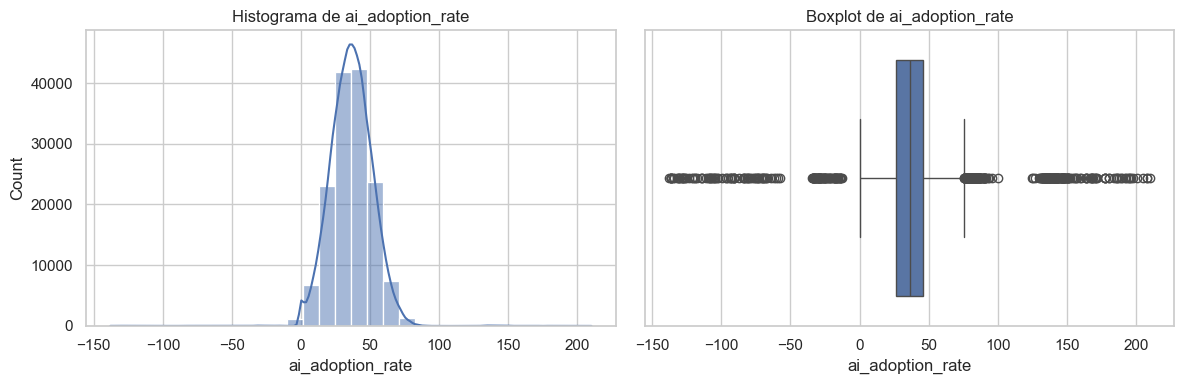


ai_maturity_score
count    150025.000000
mean          0.344678
std           0.133817
min           0.000000
25%           0.250000
50%           0.341000
75%           0.435000
max           0.904000
Name: ai_maturity_score, dtype: float64


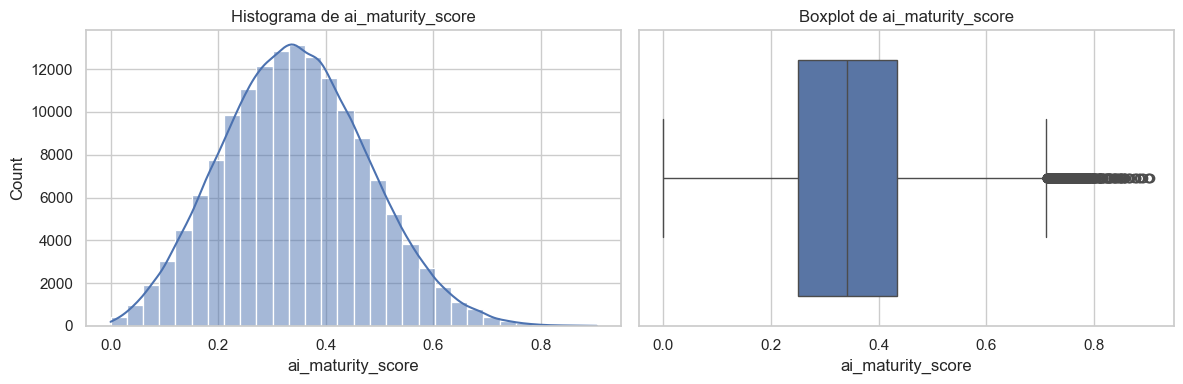


productivity_change_percent
count    150025.000000
mean          9.310881
std           6.368602
min         -57.053637
25%           5.060000
50%           9.060000
75%          13.130000
max         119.200258
Name: productivity_change_percent, dtype: float64


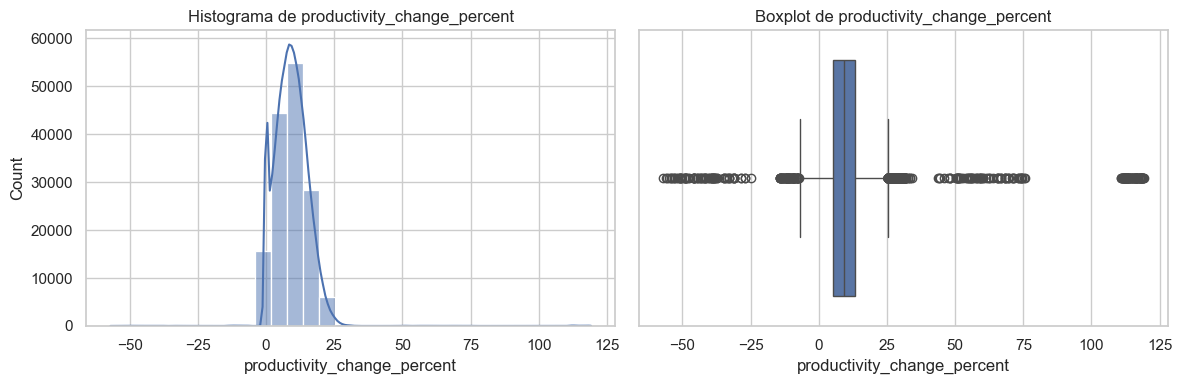

In [10]:
num_vars = ['ai_adoption_rate', 'ai_maturity_score', 'productivity_change_percent']

for col in num_vars:
    print(f'\n{col}')
    print(company[col].describe())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(company[col], bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')

    sns.boxplot(x=company[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')

    plt.tight_layout()
    plt.show()

Hay algo raro con la métrica `ai_adoption_rate`: existen tasas superiores al 100% y también inferiores al 0%. Lo mejor sería limpiar esa variable de valores atípicos.

Con respecto al `ai_maturity_score`, parece ser una métrica que va entre 0 y 1. Tiene una distribución normal con una ligera asimetría hacia la derecha. 

El `productivity_change_percent` también muestra valores negativos y mayores al 100%. Sin embargo, esto podría explicarse por una disminución, o un aumento superior al 100% (más del doble) de la productividad luego de la adopción de IA.

La siguiente celda cubre dos variables categóricas con mayor impacto interpretativo:

- `industry`: permite identificar sectores más representados y contextualizar comparaciones.
- `company_size`: muestra composición por tamaño empresarial, importante porque puede sesgar niveles de inversión/adopción.

Usamos frecuencias normalizadas (`value_counts(normalize=True)`) para que la lectura sea porcentual y comparable.


Distribucion relativa de industry (top 10):
industry
Technology       13.87
Finance          13.24
Healthcare       12.23
Manufacturing    11.51
Retail           10.76
Agriculture      10.22
Education         9.97
Logistics         8.50
Consulting        8.20
NaN               1.50
Name: proportion, dtype: float64


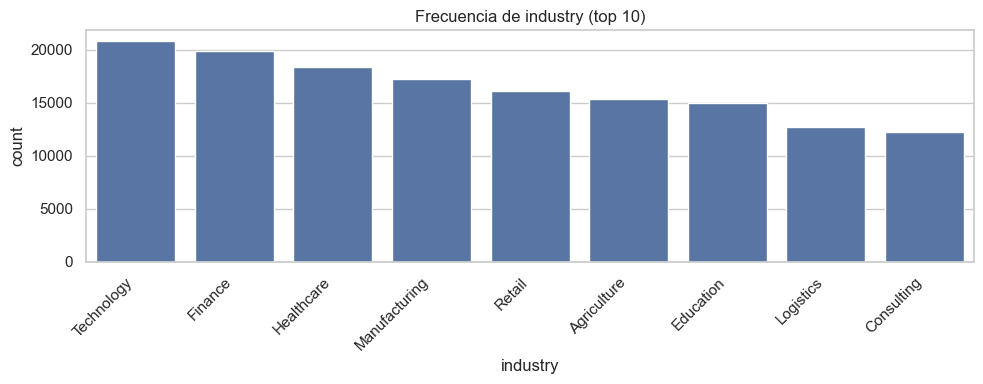


Distribucion relativa de company_size (top 10):
company_size
SME           41.96
Startup       37.23
Enterprise    19.31
NaN            1.50
Name: proportion, dtype: float64


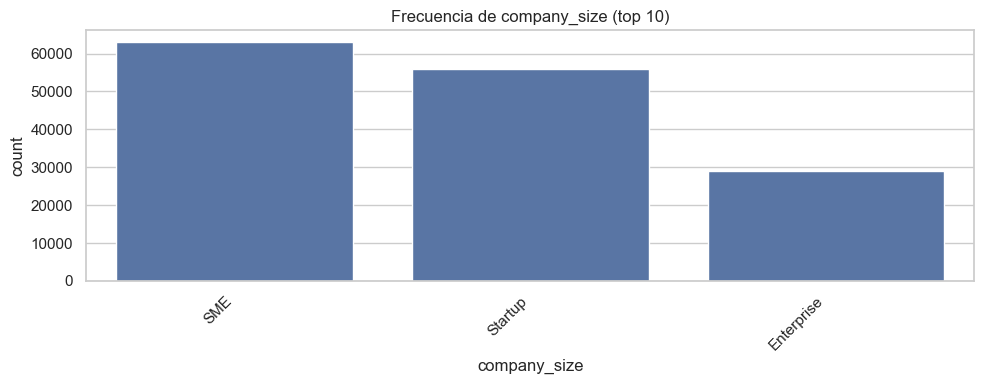

In [11]:
for col in ['industry', 'company_size']:
    dist = company[col].value_counts(dropna=False, normalize=True).head(10)
    print(f'\nDistribucion relativa de {col} (top 10):')
    print((dist * 100).round(2))

    plt.figure(figsize=(10, 4))
    sns.countplot(data=company, x=col, order=company[col].value_counts().index[:10])
    plt.title(f'Frecuencia de {col} (top 10)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 5) Análisis bivariado y comparaciones (3 relaciones)

Aquí exploramos tres relaciones alineadas con la consigna:

1. **Adopción de IA por industria**
   - Pregunta: qué sectores muestran mayor/menor tasa de adopción?
   - Gráfico: boxplot por industria para observar nivel típico y variabilidad.

2. **Inversión en IA vs cambio de productividad**
   - Pregunta: mayor inversión por empleado se asocia con mayor productividad?
   - Gráfico: dispersión con tendencia lineal (`regplot`).

3. **Diferencias entre regiones y vínculo país-madurez digital**
   - Preguntas: hay brechas de adopción por región? la madurez digital del país se relaciona con adopción promedio?
   - Gráficos: barplot por región + dispersión entre `digital_maturity_index` y adopción promedio por país.

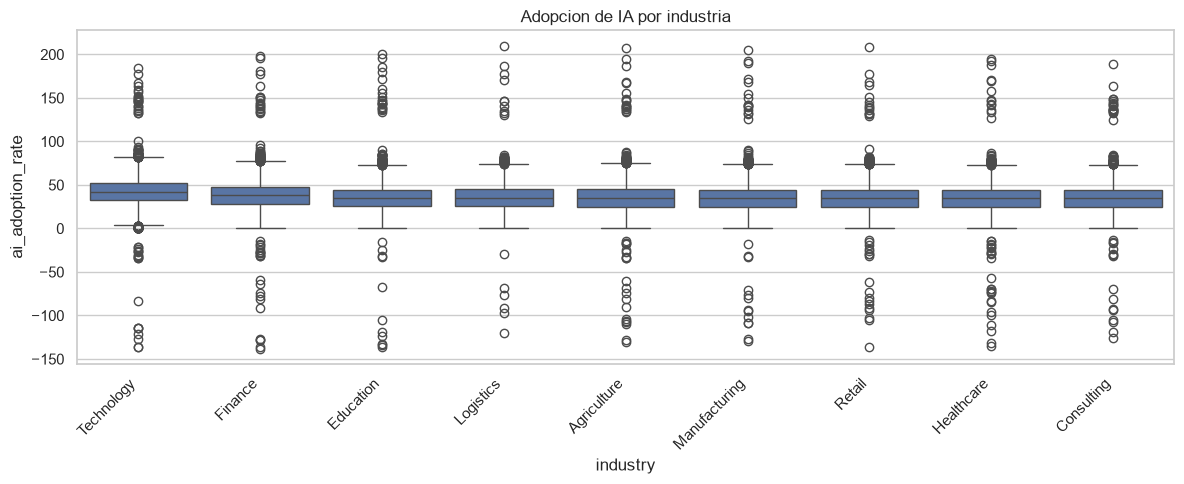

industry
Technology       42.50
Finance          38.33
Education        35.33
Logistics        35.30
Agriculture      35.22
Manufacturing    34.76
Retail           34.73
Healthcare       34.57
Consulting       34.57
Name: ai_adoption_rate, dtype: float64

In [10]:
order_industry = company.groupby('industry')['ai_adoption_rate'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 5))
sns.boxplot(data=company, x='industry', y='ai_adoption_rate', order=order_industry)
plt.title('Adopcion de IA por industria')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

company.groupby('industry')['ai_adoption_rate'].mean().sort_values(ascending=False).round(2).head(10)

No parece haber diferencias significativas entre las industrias respecto de su tasa de adopción media.

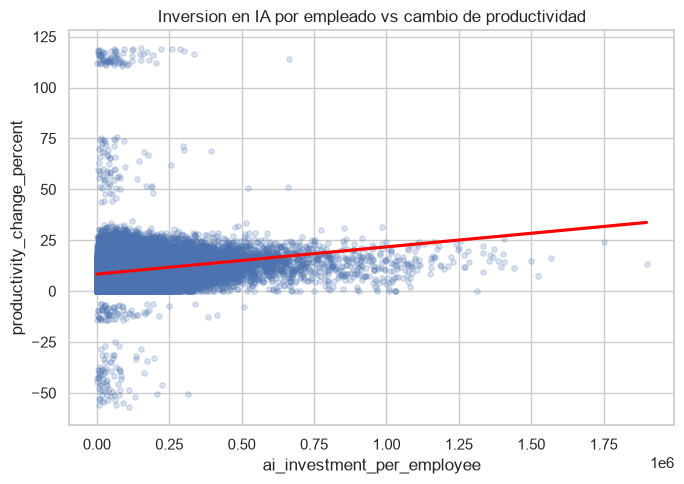

,ai_investment_per_employee,productivity_change_percent
ai_investment_per_employee,1.000,0.187
productivity_change_percent,0.187,1.000


In [14]:
# Limpiamos las variables de valores negativos y nulos para el análisis de correlación
company_clean = company[(company['ai_investment_per_employee'] >= 0)].dropna(subset=['productivity_change_percent', 'ai_investment_per_employee'])
plt.figure(figsize=(7, 5))
sns.regplot(data=company_clean, x='ai_investment_per_employee', y='productivity_change_percent', scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'color': 'red'})
plt.title('Inversion en IA por empleado vs cambio de productividad')
plt.tight_layout()
plt.show()

company_clean[['ai_investment_per_employee', 'productivity_change_percent']].corr().round(3)

La correlación entre las variables es muy baja ($R^2=0.187$) y el gráfico de dispersión da cuenta de que no hay una relación muy clara entre las variables: incluso niveles bajos de inversión están asociados a cambios grandes en la productividad, mientras que niveles altos de inversión no parecen motorizar grandes cambios. 

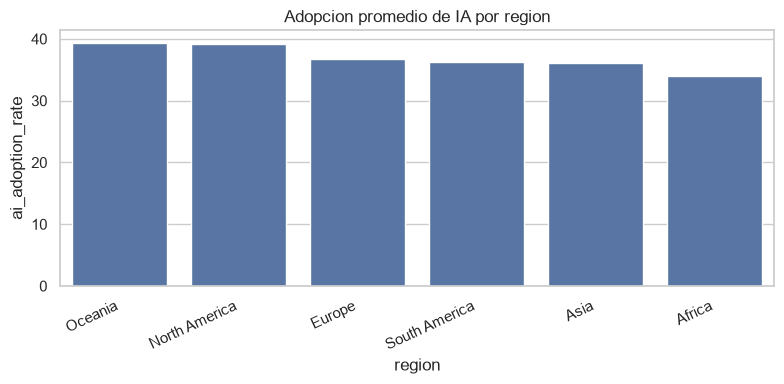

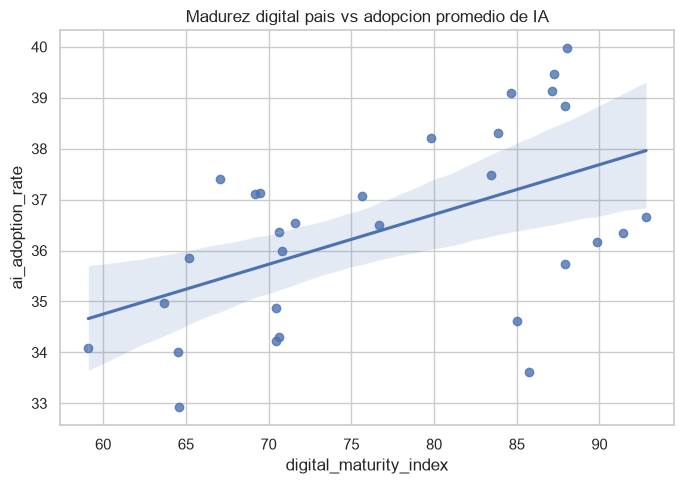

,digital_maturity_index,ai_adoption_rate
digital_maturity_index,1.000,0.521
ai_adoption_rate,0.521,1.000


In [15]:
region_mean = company.groupby('region', as_index=False)['ai_adoption_rate'].mean().sort_values('ai_adoption_rate', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=region_mean, x='region', y='ai_adoption_rate')
plt.title('Adopcion promedio de IA por region')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

country_adoption = company.groupby('country', as_index=False)['ai_adoption_rate'].mean()
country_merged = country_adoption.merge(country[['country', 'digital_maturity_index']], on='country', how='left')

plt.figure(figsize=(7, 5))
sns.regplot(data=country_merged, x='digital_maturity_index', y='ai_adoption_rate')
plt.title('Madurez digital pais vs adopcion promedio de IA')
plt.tight_layout()
plt.show()

country_merged[['digital_maturity_index', 'ai_adoption_rate']].corr().round(3)